In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [19]:
dataset = pd.read_csv('jobs.csv')

#remove all listed with no listed skills
dataset['skills'] = dataset['skills'].fillna('')
dataset = dataset[dataset['skills'] != '']

#convert skills string to list object
dataset['skills_list'] = dataset['skills'].apply(lambda x: [skill.strip() for skill in x.split(',') if skill.strip()])

dataset.head()

,company,title,location,skills,degree,url,skills_list
0,trase,"Director of Product Management, National Security","McLean, VA",Go,NaN,https://job-boards.greenhouse.io/trase/jobs/47...,[Go]
2,trase,"ML Engineer, Applied Machine Learning","Seattle, WA","Python, TensorFlow, PyTorch",NaN,https://job-boards.greenhouse.io/trase/jobs/47...,"[Python, TensorFlow, PyTorch]"
3,trase,"ML Researcher, Applied Machine Learning","Seattle, WA","Python, TensorFlow, PyTorch",NaN,https://job-boards.greenhouse.io/trase/jobs/47...,"[Python, TensorFlow, PyTorch]"
4,trase,Principal MLOps Engineer,"Remote; Seattle, WA; McClean, VA","Python, AWS, GCP, Azure, Docker, Kubernetes, T...",NaN,https://job-boards.greenhouse.io/trase/jobs/49...,"[Python, AWS, GCP, Azure, Docker, Kubernetes, ..."
5,trase,"Principal Software Engineer, Backend Engineeri...","Remote; Seattle, WA; McLean, VA","Python, TypeScript, Go, gRPC, REST, AWS, GCP, ...",NaN,https://job-boards.greenhouse.io/trase/jobs/49...,"[Python, TypeScript, Go, gRPC, REST, AWS, GCP,..."


In [20]:
#convert data into numeric features
mlb = MultiLabelBinarizer()
X = mlb.fit_transform(dataset['skills_list'])

X.shape

(4833, 97)

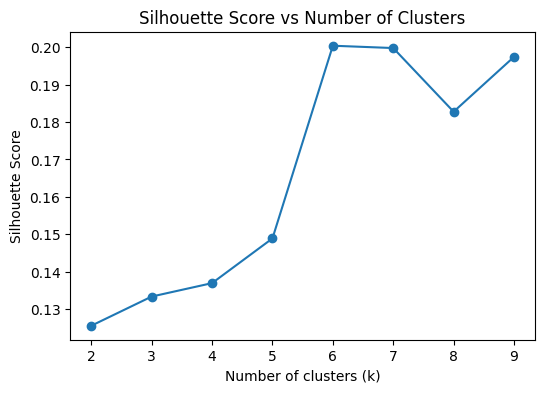

6

In [21]:
#find number of clusters with silhouette score
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

#sil score plot
plt.figure(figsize=(6,4))
plt.plot(k_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

#find best k with highest sil score
best_k = k_range[np.argmax(sil_scores)]
best_k

In [22]:
#run kmeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
dataset['cluster'] = kmeans.fit_predict(X)

In [23]:
#create cluster labels based on top skills
cluster_labels = {}

for cluster_num in range(best_k):
    cluster_skills = X[dataset['cluster']==cluster_num].sum(axis=0)
    top_skills_idx = np.argsort(cluster_skills)[::-1][:5]
    top_skills = [mlb.classes_[i] for i in top_skills_idx]

    #creates labels
    if any(skill.lower() in ['python', 'tensorflow', 'pytorch', 'ml', 'ai'] for skill in top_skills):
        label = "ML/AI"
    elif any(skill.lower() in ['aws', 'gcp', 'azure', 'docker', 'kubernetes', 'ci/cd', 'terraform'] for skill in top_skills):
        label = "Cloud/DevOps"
    elif any(skill.lower() in ['go', 'typescript', 'grpc', 'rest'] for skill in top_skills):
        label = "Backend/Software Engineering"
    else:
        label = "Other"
    cluster_labels[cluster_num] = label

dataset['cluster_label'] = dataset['cluster'].map(cluster_labels)

dataset.head()

,company,title,location,skills,degree,url,skills_list,cluster,cluster_label
0,trase,"Director of Product Management, National Security","McLean, VA",Go,NaN,https://job-boards.greenhouse.io/trase/jobs/47...,[Go],0,Backend/Software Engineering
2,trase,"ML Engineer, Applied Machine Learning","Seattle, WA","Python, TensorFlow, PyTorch",NaN,https://job-boards.greenhouse.io/trase/jobs/47...,"[Python, TensorFlow, PyTorch]",5,ML/AI
3,trase,"ML Researcher, Applied Machine Learning","Seattle, WA","Python, TensorFlow, PyTorch",NaN,https://job-boards.greenhouse.io/trase/jobs/47...,"[Python, TensorFlow, PyTorch]",5,ML/AI
4,trase,Principal MLOps Engineer,"Remote; Seattle, WA; McClean, VA","Python, AWS, GCP, Azure, Docker, Kubernetes, T...",NaN,https://job-boards.greenhouse.io/trase/jobs/49...,"[Python, AWS, GCP, Azure, Docker, Kubernetes, ...",3,ML/AI
5,trase,"Principal Software Engineer, Backend Engineeri...","Remote; Seattle, WA; McLean, VA","Python, TypeScript, Go, gRPC, REST, AWS, GCP, ...",NaN,https://job-boards.greenhouse.io/trase/jobs/49...,"[Python, TypeScript, Go, gRPC, REST, AWS, GCP,...",3,ML/AI


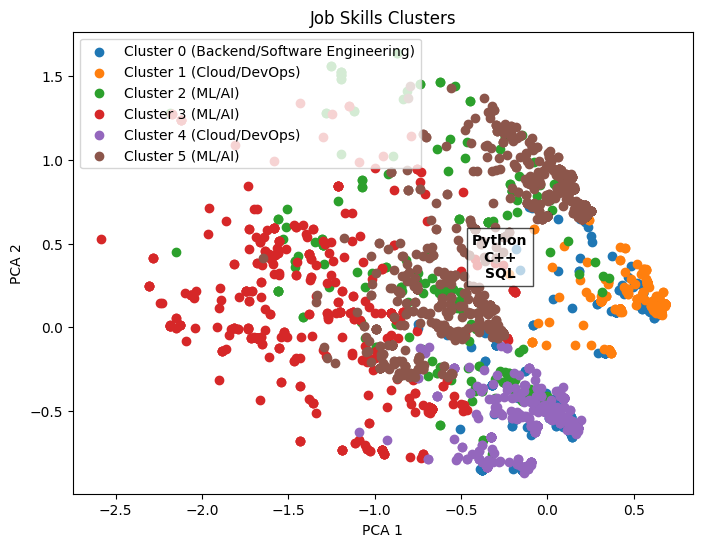

In [ ]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8,6))
for cluster in range(best_k):
    plt.scatter(X_2d[dataset['cluster']==cluster, 0],
                X_2d[dataset['cluster']==cluster, 1],
                label=f"Cluster {cluster} ({cluster_labels[cluster]})")
plt.legend()
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Job Skills Clusters")
plt.show()